In [2]:
## READ ME: Run all the blocks in order and the code will all work. I've split the blocks into a manner I thought logical. At the top of
## each block is a summary of what that block contains. I've limited most comments apart from that just to preserve simplicity.

In [2]:
## LOAD DATA

import os
import pandas as pd
import numpy as np

# define the base path
base_path = "A2/2025_A2"

# define the paths to train and test folders
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

# metadata
train_metadata = pd.read_csv(os.path.join(train_path, "train_metadata.csv"))
test_metadata = pd.read_csv(os.path.join(test_path, "test_metadata.csv"))

# training features
train_features_path = os.path.join(train_path, "Features")
train_additional = pd.read_csv(os.path.join(train_features_path, "additional_features.csv"))
train_colorhist = pd.read_csv(os.path.join(train_features_path, "color_histogram.csv"))
train_hogpca = pd.read_csv(os.path.join(train_features_path, "hog_pca.csv"))

# test features
test_features_path = os.path.join(test_path, "Features")
test_additional = pd.read_csv(os.path.join(test_features_path, "additional_features.csv"))
test_colorhist = pd.read_csv(os.path.join(test_features_path, "color_histogram.csv"))
test_hogpca = pd.read_csv(os.path.join(test_features_path, "hog_pca.csv"))

# now combine the training and test features
features_train = pd.concat([train_additional, train_colorhist, train_hogpca], axis=1)
features_test = pd.concat([test_additional, test_colorhist, test_hogpca], axis=1)

# drop 'image_path' column if it exists -> this was causing some form of error
features_train = features_train.drop(columns=["image_path"], errors="ignore")
features_test = features_test.drop(columns=["image_path"], errors="ignore")

# labels innit
labels_train = train_metadata["ClassId"]

In [4]:
## PREPROCESSING

from sklearn.preprocessing import StandardScaler

# scale features
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

In [6]:
## SPLIT INTO TRAIN AND TEST

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    features_train_scaled,
    labels_train,
    test_size=0.2,
    stratify=labels_train, # stratified sampling innit, ensures class distribution is preserved
    random_state=69
)

In [30]:
## MODEL 1 - KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialise the model
knn = KNeighborsClassifier(n_neighbors=5)

# Now train it
knn.fit(X_train, y_train)

# Then predict on validation set
knn_predictions = knn.predict(X_val)

# now evaluate it's performance

print("kNN Accuracy:", accuracy_score(y_val, knn_predictions))
print("\nClassification Report:\n", classification_report(y_val, knn_predictions, zero_division=0))

kNN Accuracy: 0.6029143897996357

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.49      0.63      0.55        62
           2       0.42      0.67      0.52        63
           3       0.53      0.72      0.61        39
           4       0.44      0.75      0.55        55
           5       0.46      0.52      0.49        52
           6       0.82      0.75      0.78        12
           7       0.50      0.60      0.55        40
           8       0.62      0.62      0.62        39
           9       0.59      0.46      0.52        41
          10       0.72      0.64      0.68        56
          11       0.38      0.62      0.47        37
          12       0.92      0.83      0.88        59
          13       0.85      0.78      0.82        60
          14       1.00      0.73      0.84        22
          15       0.89      0.44      0.59        18
          16       0.89

In [24]:
## MODEL 2 - SVM

from sklearn.svm import SVC

# Initialise model
svm = SVC(kernel = 'rbf', C=1, gamma = 'scale')

# Train it
svm.fit(X_train, y_train)

# Now predict on the validation set
svm_predictions = svm.predict(X_val)

# Now let's evaluate it's performance

print("SVM Accuracy:", accuracy_score(y_val, svm_predictions))
print("\nClassification Report (SVM):")
print(classification_report(y_val, svm_predictions, zero_division=0))

SVM Accuracy: 0.7422586520947176

Classification Report (SVM):
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         6
           1       0.54      0.85      0.66        62
           2       0.69      0.78      0.73        63
           3       0.73      0.62      0.67        39
           4       0.68      0.84      0.75        55
           5       0.45      0.52      0.48        52
           6       0.79      0.92      0.85        12
           7       0.76      0.65      0.70        40
           8       0.60      0.64      0.62        39
           9       0.86      0.73      0.79        41
          10       0.85      0.93      0.89        56
          11       0.53      0.81      0.64        37
          12       1.00      0.97      0.98        59
          13       0.98      0.97      0.97        60
          14       1.00      0.95      0.98        22
          15       1.00      0.56      0.71        18
          16      

In [32]:
## MODEL 3 - RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

# Initialise it
random_forest_model = RandomForestClassifier(n_estimators = 100, random_state = 69)

# Train it
random_forest_model.fit(X_train, y_train)

# Predict
random_forest_predictions = random_forest_model.predict(X_val)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_val, random_forest_predictions))
print("\nClassification Report (Random Forest):")
print(classification_report(y_val, random_forest_predictions, zero_division=0))

Random Forest Accuracy: 0.7896174863387978

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.64      0.84      0.73        62
           2       0.60      0.83      0.69        63
           3       0.79      0.59      0.68        39
           4       0.64      0.69      0.67        55
           5       0.74      0.60      0.66        52
           6       0.91      0.83      0.87        12
           7       0.82      0.57      0.68        40
           8       0.71      0.77      0.74        39
           9       0.84      0.88      0.86        41
          10       0.84      0.93      0.88        56
          11       0.53      0.78      0.63        37
          12       0.91      1.00      0.95        59
          13       1.00      1.00      1.00        60
          14       1.00      0.91      0.95        22
          15       0.93      0.72      0.81        1

In [20]:
## MODEL 4 - MLP (NEURAL NETWORK)

from sklearn.neural_network import MLPClassifier

# Initialise it
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    early_stopping=True,
    random_state=69,
    verbose=True
)

# Train it
mlp_model.fit(X_train, y_train)

# Predict
mlp_predictions = mlp_model.predict(X_val)

# Evaluate
print("MLP Accuracy:", accuracy_score(y_val, mlp_predictions))
print("\nClassification Report (MLP):")
print(classification_report(y_val, mlp_predictions, zero_division=0))

Iteration 1, loss = 3.67075415
Validation score: 0.134396
Iteration 2, loss = 3.14780792
Validation score: 0.261959
Iteration 3, loss = 2.80019456
Validation score: 0.369021
Iteration 4, loss = 2.49977197
Validation score: 0.432802
Iteration 5, loss = 2.24009652
Validation score: 0.471526
Iteration 6, loss = 2.00810908
Validation score: 0.496583
Iteration 7, loss = 1.80661955
Validation score: 0.530752
Iteration 8, loss = 1.62946333
Validation score: 0.530752
Iteration 9, loss = 1.47458076
Validation score: 0.560364
Iteration 10, loss = 1.34175828
Validation score: 0.564920
Iteration 11, loss = 1.22545157
Validation score: 0.594533
Iteration 12, loss = 1.12412477
Validation score: 0.621868
Iteration 13, loss = 1.03771569
Validation score: 0.633257
Iteration 14, loss = 0.96239180
Validation score: 0.651481
Iteration 15, loss = 0.89607630
Validation score: 0.644647
Iteration 16, loss = 0.83819688
Validation score: 0.669704
Iteration 17, loss = 0.78564880
Validation score: 0.683371
Iterat

In [16]:
## TUNING RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# define the parameter grid
param_grid_random_forest = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 30, 50],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# set up GridSearchCV - this basically runs 36 models across 3 folds each (so 108 fits in total)
grid_search_random_forest = GridSearchCV(
    estimator=RandomForestClassifier(random_state=69),
    param_grid=param_grid_random_forest,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

# fit the model
grid_search_random_forest.fit(X_train, y_train)

# results
print("Best CV Score:", grid_search_random_forest.best_score_)
print("Best Params:", grid_search_random_forest.best_params_)

# evaluate on validation set
best_rf_model = grid_search_random_forest.best_estimator_
y_val_pred = best_rf_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, zero_division=0))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best CV Score: 0.7523910994575359
Best Params: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Validation Accuracy: 0.7987249544626593

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.67      0.90      0.77        62
           2       0.64      0.81      0.71        63
           3       0.74      0.59      0.66        39
           4       0.66      0.69      0.67        55
           5       0.73      0.62      0.67        52
           6       1.00      0.83      0.91        12
           7       0.86      0.60      0.71        40
           8       0.74      0.72      0.73        39
           9       0.77      0.83      0.80        41
          10       0.82      0.91      0.86        56
          11       0.55      0.81      0.65        37
          12       0.94      1.00    

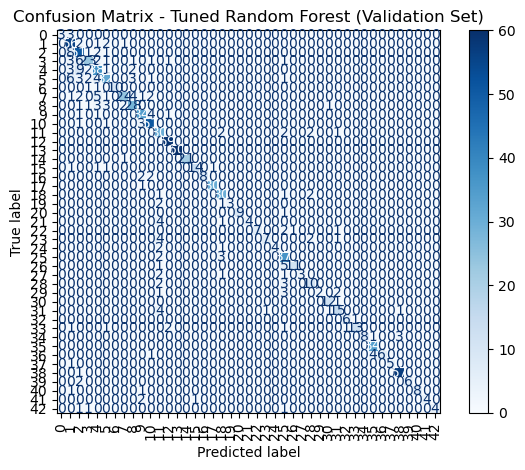

In [29]:
## CONFUSION MATRIX FOR TUNED RF MODEL

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_rf_model, X_val, y_val, 
    display_labels=range(43),  # class labels 0 to 42
    cmap='Blues',
    xticks_rotation='vertical'
)

plt.title("Confusion Matrix - Tuned Random Forest (Validation Set)")
plt.tight_layout()
plt.show()

In [26]:
# KAGGLE SUBMISSION

# use actual 'id' column from test metadata (not derived from image_path)
test_ids = test_metadata["id"]

# used the tuned RF to predict
random_forest_test_predictions = best_rf_model.predict(features_test_scaled)

# create the submission dataframe
submission_df = pd.DataFrame({
    "id": test_ids,
    "ClassId": random_forest_test_predictions
})

# save to CSV
submission_df.to_csv("submission.csv", index=False)